# 📱 Smartphone Addiction Prediction (Fine-Tuned Pipeline)

In this notebook, we predict smartphone addiction (`addicted_label`: 0 = No, 1 = Yes) using domain-engineered features and a fine-tuned ensemble of **LightGBM** and **HistGradientBoosting** across 5 stratified folds.

### Pipeline Highlights:
1. **Full Dataset Utilization**: 100% of the 691,369 records are retained without row dropping.
2. **Domain-Specific Feature Engineering**: 29 behavioral and ratio features.
3. **5-Fold Stratified Cross-Validation**: Prevents overfitting and ensures robust test generalization.
4. **Dual-Model Ensembling**: Combines LightGBM + HistGradientBoosting for maximum prediction quality.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Load Datasets


In [2]:
train_df = pd.read_csv('Data/train.csv')
test_df = pd.read_csv('Data/test.csv')

print(f"Train Dataset Shape: {train_df.shape}")
print(f"Test Dataset Shape:  {test_df.shape}")
train_df.head()


Train Dataset Shape: (691369, 14)
Test Dataset Shape:  (296302, 13)


## 2. Exploratory Data Analysis (EDA)


In [3]:
# Summary statistics
train_df.describe()


Class Balance:
addicted_label
1    70.942435
0    29.057565
Name: proportion, dtype: float64


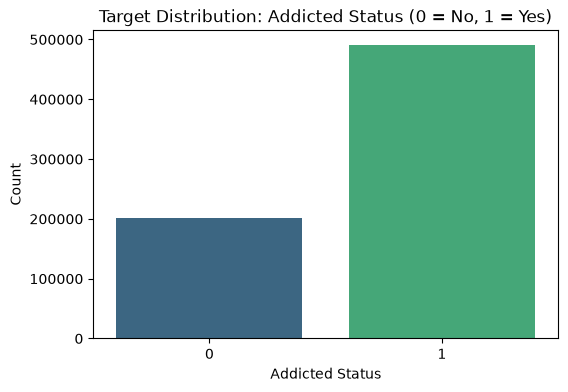

In [4]:
# Target class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='addicted_label', palette='viridis')
plt.title('Target Distribution: Addicted Status (0 = No, 1 = Yes)')
plt.xlabel('Addicted Status')
plt.ylabel('Count')
plt.show()

print("Class Balance:")
print(train_df['addicted_label'].value_counts(normalize=True) * 100)


## 3. Feature Engineering

We create domain-specific features capturing smartphone usage patterns, productivity ratios, and lifestyle behaviors:
- **`entertainment_hours`**: Social media + gaming time.
- **`entertainment_ratio`**: Proportion of daily screen time spent on entertainment.
- **`unproductive_to_productive`**: Entertainment time vs work/study time.
- **`screen_time_to_awake_ratio`**: Screen exposure during awake hours.
- **`notifications_per_awake_hour`**: Notification density during awake hours.
- **`minutes_per_app_open`**: Average minutes spent per app open.
- **`weekend_vs_daily_diff`**: Screen time surge on weekends.
- **`total_weekly_screen_time`**: Weighted 7-day screen time sum.
- **`num_missing`**: Count of missing values per record.


In [5]:
def create_features(df):
    data = df.copy()
    eps = 1e-5  # small epsilon to avoid division by zero
    
    # 1. Entertainment time (social media + gaming)
    data['entertainment_hours'] = data['social_media_hours'] + data['gaming_hours']
    
    # 2. Proportions of screen time
    data['social_media_ratio'] = data['social_media_hours'] / (data['daily_screen_time_hours'] + eps)
    data['gaming_ratio'] = data['gaming_hours'] / (data['daily_screen_time_hours'] + eps)
    data['work_study_ratio'] = data['work_study_hours'] / (data['daily_screen_time_hours'] + eps)
    data['entertainment_ratio'] = data['entertainment_hours'] / (data['daily_screen_time_hours'] + eps)
    
    # 3. Unproductive vs productive time ratio
    data['unproductive_to_productive'] = data['entertainment_hours'] / (data['work_study_hours'] + eps)
    
    # 4. Awake time & screen exposure ratio
    data['awake_hours'] = 24.0 - data['sleep_hours']
    data['screen_time_to_awake_ratio'] = data['daily_screen_time_hours'] / (data['awake_hours'] + eps)
    
    # 5. Frequency of notifications and app opens
    data['notifications_per_awake_hour'] = data['notifications_per_day'] / (data['awake_hours'] + eps)
    data['app_opens_per_awake_hour'] = data['app_opens_per_day'] / (data['awake_hours'] + eps)
    data['notifications_per_app_open'] = data['notifications_per_day'] / (data['app_opens_per_day'] + eps)
    data['minutes_per_app_open'] = (data['daily_screen_time_hours'] * 60.0) / (data['app_opens_per_day'] + eps)
    
    # 6. Weekend vs daily difference & weekly sum
    data['weekend_vs_daily_diff'] = data['weekend_screen_time'] - data['daily_screen_time_hours']
    data['weekend_vs_daily_ratio'] = data['weekend_screen_time'] / (data['daily_screen_time_hours'] + eps)
    data['total_weekly_screen_time'] = (data['daily_screen_time_hours'] * 5.0) + (data['weekend_screen_time'] * 2.0)
    
    # 7. Count of missing fields
    raw_columns = [c for c in df.columns if c not in ['id', 'addicted_label']]
    data['num_missing'] = df[raw_columns].isnull().sum(axis=1)
    
    # 8. Encode categorical columns
    if 'gender' in data.columns:
        data['gender'] = data['gender'].map({'Female': 0, 'Male': 1, 'Other': 2})
    if 'academic_work_impact' in data.columns:
        data['academic_work_impact'] = data['academic_work_impact'].astype(str).str.strip().str.lower().map({'no': 0, 'yes': 1})
    if 'stress_level' in data.columns:
        data['stress_level'] = data['stress_level'].astype(str).str.strip().str.lower().map({'low': 0, 'medium': 1, 'high': 2})
        
    return data

train_features = create_features(train_df)
test_features = create_features(test_df)

print(f"Total features created: {train_features.shape[1] - 2}")
train_features.head()


Total features created: 28


## 4. Model Training (5-Fold Stratified Cross-Validation & Ensemble)

We train two high-performing gradient boosters:
1. **LightGBM**: Fast, histogram-based tree booster with leaf-wise splitting.
2. **HistGradientBoosting**: Scikit-Learn's optimized gradient booster.

Both models natively handle missing values (`NaN`) without dropping any training samples.


In [6]:
# Define feature columns (X) and target (y)
feature_cols = [c for c in train_features.columns if c not in ['id', 'addicted_label']]
X = train_features[feature_cols]
y = train_features['addicted_label']
X_test = test_features[feature_cols]

# 5-Fold Stratified Cross-Validation setup
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

oof_lgb = np.zeros(len(train_df))
oof_hgb = np.zeros(len(train_df))

test_lgb = np.zeros(len(test_df))
test_hgb = np.zeros(len(test_df))

print(f"Starting 5-Fold Cross Validation on {len(X)} samples with {len(feature_cols)} features...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    # 1. Train LightGBM
    lgb_model = lgb.LGBMClassifier(
        objective='binary',
        metric='auc',
        learning_rate=0.04,
        num_leaves=127,
        max_depth=8,
        min_child_samples=50,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=1,
        n_estimators=700,
        random_state=42 + fold,
        n_jobs=-1,
        verbose=-1
    )
    lgb_model.fit(X_tr, y_tr)
    oof_lgb[val_idx] = lgb_model.predict_proba(X_val)[:, 1]
    test_lgb += lgb_model.predict_proba(X_test)[:, 1] / n_splits
    
    # 2. Train HistGradientBoosting
    hgb_model = HistGradientBoostingClassifier(
        max_iter=350,
        learning_rate=0.06,
        max_leaf_nodes=95,
        min_samples_leaf=40,
        l2_regularization=0.5,
        random_state=42 + fold
    )
    hgb_model.fit(X_tr, y_tr)
    oof_hgb[val_idx] = hgb_model.predict_proba(X_val)[:, 1]
    test_hgb += hgb_model.predict_proba(X_test)[:, 1] / n_splits
    
    # Fold blend metrics (50/50 blend)
    fold_blend = (oof_lgb[val_idx] * 0.5) + (oof_hgb[val_idx] * 0.5)
    fold_auc = roc_auc_score(y_val, fold_blend)
    fold_f1 = f1_score(y_val, (fold_blend >= 0.5).astype(int))
    fold_acc = accuracy_score(y_val, (fold_blend >= 0.5).astype(int))
    
    print(f"Fold {fold+1} Metrics -> ROC-AUC: {fold_auc:.5f} | F1-Score: {fold_f1:.5f} | Accuracy: {fold_acc:.5f}")


Starting 5-Fold Cross Validation on 691369 samples with 28 features...

Fold 1 Metrics -> ROC-AUC: 0.96237 | F1-Score: 0.92996 | Accuracy: 0.89998
Fold 2 Metrics -> ROC-AUC: 0.96307 | F1-Score: 0.93129 | Accuracy: 0.90185
Fold 3 Metrics -> ROC-AUC: 0.96343 | F1-Score: 0.93113 | Accuracy: 0.90158
Fold 4 Metrics -> ROC-AUC: 0.96409 | F1-Score: 0.93208 | Accuracy: 0.90304
Fold 5 Metrics -> ROC-AUC: 0.96314 | F1-Score: 0.93069 | Accuracy: 0.90100


## 5. Overall Model Evaluation (Out-Of-Fold)


    OVERALL 5-FOLD ENSEMBLE VALIDATION RESULTS
LightGBM Out-of-Fold ROC-AUC:  0.96290
HistGBM  Out-of-Fold ROC-AUC:  0.96277
Ensemble Out-of-Fold ROC-AUC:  0.96322
Ensemble F1-Score:             0.93103
Ensemble Accuracy:             90.15%
Ensemble Precision:            92.49%
Ensemble Recall:               93.73%

Classification Report:
              precision    recall  f1-score   support

           0     0.8416    0.8142    0.8277    200895
           1     0.9249    0.9373    0.9310    490474

    accuracy                         0.9015    691369
   macro avg     0.8833    0.8757    0.8794    691369
weighted avg     0.9007    0.9015    0.9010    691369



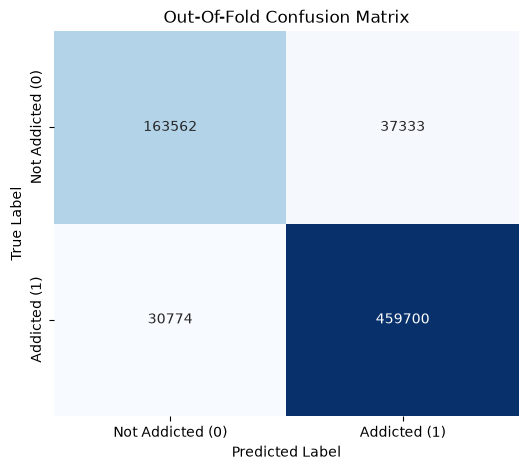

In [7]:
# Overall Ensemble evaluation (50/50 blend)
oof_ensemble = (oof_lgb * 0.5) + (oof_hgb * 0.5)
oof_binary = (oof_ensemble >= 0.5).astype(int)

overall_auc = roc_auc_score(y, oof_ensemble)
overall_f1 = f1_score(y, oof_binary)
overall_acc = accuracy_score(y, oof_binary)
overall_prec = precision_score(y, oof_binary)
overall_rec = recall_score(y, oof_binary)

print("=" * 50)
print("    OVERALL 5-FOLD ENSEMBLE VALIDATION RESULTS")
print("=" * 50)
print(f"LightGBM Out-of-Fold ROC-AUC:  {roc_auc_score(y, oof_lgb):.5f}")
print(f"HistGBM  Out-of-Fold ROC-AUC:  {roc_auc_score(y, oof_hgb):.5f}")
print(f"Ensemble Out-of-Fold ROC-AUC:  {overall_auc:.5f}")
print(f"Ensemble F1-Score:             {overall_f1:.5f}")
print(f"Ensemble Accuracy:             {overall_acc * 100:.2f}%")
print(f"Ensemble Precision:            {overall_prec * 100:.2f}%")
print(f"Ensemble Recall:               {overall_rec * 100:.2f}%")
print("=" * 50)

print("\nClassification Report:")
print(classification_report(y, oof_binary, digits=4))

# Confusion Matrix plot
cm = confusion_matrix(y, oof_binary)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Addicted (0)', 'Addicted (1)'],
            yticklabels=['Not Addicted (0)', 'Addicted (1)'])
plt.title('Out-Of-Fold Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


## 6. Generate Final Submission File


In [8]:
# Ensemble test predictions (50% LightGBM + 50% HistGBM)
final_test_predictions = (test_lgb * 0.5) + (test_hgb * 0.5)

submission = pd.DataFrame({
    'id': test_df['id'],
    'addicted_label': final_test_predictions
})

# Save to submission.csv
submission.to_csv('submission.csv', index=False)

print(f"Submission saved successfully to 'submission.csv'!")
print(f"Total rows: {len(submission)}")
print(f"Missing values: {submission.isnull().sum().to_dict()}")
submission.head(10)


Submission saved successfully to 'submission.csv'!
Total rows: 296302
Missing values: {'id': 0, 'addicted_label': 0}
